# Discrete Diffusion for Markov Chains

Suppose we're trying to model a data generating distribution that is a Markov chain,
\begin{align*}
q_0(x_{1:D}) &= q_0(x_1) \prod_{d=2}^D q_0(x_d \mid x_{d-1})
\end{align*}
where $x_d \in [K]$ and $q_0(x_d = j \mid x_{d-1}=i) = R_{ij}$.

We're going to approximate this model with a masked diffusion model where at each time step of the diffusion process, tokens randomly and independently transition into the mask state ($x_d = \varnothing$) with some probability $\rho_t$.

The forward probability of the diffusion state at time $t$ is thus given by,
\begin{align*}
q_{t|0}(x^{(t)}_{1:D} \mid x^{(0)}_{1:D}) &= \prod_{d=1}^D \left[ 1 - \rho_t\right]^{\mathbb{I}[x_{d}^{(t)} = x_d^{(0)}]} \rho_t^{\mathbb{I}[x_{d}^{(t)} = \varnothing]}
\end{align*}
(Note: there is zero probability of $x_d^{(t)} \notin \{\varnothing,  x_d^{(0)}\}$.)

Thus, the backward probability is,
\begin{align*}
q_{0|t}(x_{1:D}^{(0)} \mid x_{1:D}^{(t)})
&\propto q_0(x_{1:D}^{(0)}) \, q_{t|0}(x_{1:D}^{(t)} \mid x_{1:D}^{(0)}).
\end{align*}
**This is the posterior probability of the states in a hidden Markov model!**


## Experiment

Suppose that the generative model has learned the correct backward probabilities. We ask, how well can we approximate samples from the true Markov chain using a finite number of predictor steps $N_P$ and corrector steps $N_C$?

Assume the predictor has access to the backward marginals,
\begin{align*}
q_{0|t}(x_d^{(0)} \mid x_{\neg d}^{(t)}, x_d^{(t)} = \varnothing)
&\propto \alpha_d(x_d^{(0)} \mid x_{1:d-1}^{(t)}) \, \beta_d(x_d^{(0)} \mid x_{d+1:D}^{(t)}),
\end{align*}
where $\alpha_d$ and $\beta_d$ are the forward and backward messages, respectively.

For the **predictor**, we assume that each predictor step unmasks a random number of tokens by sampling _independently_ from the backward marginals. The fact that these tokens are generated independently means that the predictor can introduce errors; i.e., it can generate low (or even zero!) probability state sequences.

The **corrector** applies $K$ "Gibbs" iterations by sampling the conditional
\begin{align*}
q_{t}(x_d^{(t)} \mid x_{\neg d}^{(t)}, x_d^{(t)} \neq \varnothing)
\end{align*}
Under a masked diffusion, this is equivalent to the backward marginal above. We have several strategies for how to pick which $K$ sites to update, but we'll get to that below.

To evaluate performance, we will compute the expected log likelihood of the generated sequences $x_{1:D}^{(0)}$ under the true marginal $q_0(x_{1:D})$. If the backward process was exact (e.g., if the predictor unmasked one token at a time), then the expected log likelihood would be the negative entropy of $q_0$. For approximate predictor/corrector schemes, the expected log likelihood is the negative cross-entropy of the approximate to the true marginal.




In [1]:
# !pip install jaxtyping

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt

from functools import partial
from jax import lax
from jax.nn import one_hot
from jaxtyping import Float, Array

In [2]:
MASK = -1

def sample_markov_chain(key: jr.PRNGKey,
                        trans_matrix: Float[Array, "num_states num_states"],
                        seq_length: int):
    """Sample a Markov chain from a transition matrix."""
    k1, key = jr.split(key)
    K = trans_matrix.shape[0]
    x1 = jr.categorical(k1, jnp.zeros(K))

    def _step(prev_state, k2):
        next_state = jr.categorical(k2, jnp.log(trans_matrix[prev_state]))
        return next_state, next_state

    _, states = lax.scan(_step, x1, jr.split(key, seq_length-1))
    return jnp.concatenate([jnp.array([x1]), states])

In [3]:
def forward_messages(masked_states: Float[Array, "seq_length"],
                     trans_matrix: Float[Array, "num_states num_states"]):
    """
    Compute the forward probabilities of each latent state given preceding observations.
    """
    K = trans_matrix.shape[0]
    alpha_1 = jnp.ones(K) / K

    def _step(prev_alpha, obs):
        # update based on observation
        alpha = lax.cond(obs == MASK,
                         lambda: prev_alpha,
                         lambda: one_hot(obs, K)
                         )

        # predict
        alpha = alpha @ trans_matrix
        return alpha, prev_alpha

    _, alphas = lax.scan(_step, alpha_1, masked_states)
    return alphas


In [4]:
def backward_messages(masked_states: Float[Array, "seq_length"],
                      trans_matrix: Float[Array, "num_states num_states"]):
    """
    Compute the backward probabilities of each latent state given subsequent observations.
    """
    K = trans_matrix.shape[0]
    beta_T = jnp.ones(K) / K

    def _step(next_beta, obs):
        # update based on observation
        beta = lax.cond(obs == MASK,
                        lambda: next_beta,
                        lambda: one_hot(obs, K)
                        )

        # predict
        beta = trans_matrix @ beta
        beta = beta / beta.sum()
        return beta, next_beta

    _, betas = lax.scan(_step, beta_T, masked_states, reverse=True)
    return betas

In [5]:
def compute_posterior_marginals(masked_states: Float[Array, "seq_length"],
                                trans_matrix: Float[Array, "num_states num_states"]):
    """
    Compute the posterior marginal distributions
    """
    alphas = forward_messages(masked_states, trans_matrix)
    betas = backward_messages(masked_states, trans_matrix)
    marginals = alphas * betas
    marginals /= marginals.sum(axis=1, keepdims=True)
    return marginals

In [6]:
# Test
k1, k2 = jr.split(jr.PRNGKey(0), 2)
num_states = 4
seq_len = 50
self_trans_prob = 0.9

trans_matrix = self_trans_prob * jnp.eye(num_states) \
             + (1 - self_trans_prob) * jnp.roll(jnp.eye(num_states), 1, axis=1)
true_states = sample_markov_chain(k1, trans_matrix, seq_len)

mask = jr.bernoulli(k2, 0.5, shape=(seq_len,))
masked_states = jnp.where(mask, MASK, true_states)

alphas = forward_messages(masked_states, trans_matrix)
assert jnp.allclose(alphas.sum(1), 1.0)
betas = backward_messages(masked_states, trans_matrix)
marginals = compute_posterior_marginals(masked_states, trans_matrix)
assert jnp.allclose(marginals.sum(1), 1.0)

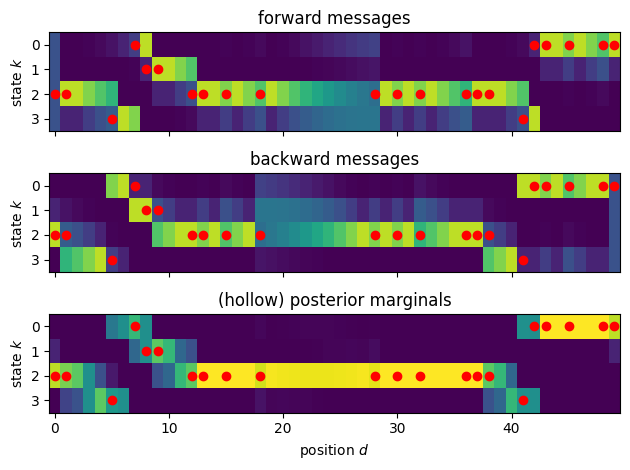

In [7]:
fig, axs = plt.subplots(3, 1, sharex=True)
axs[0].imshow(alphas.T, aspect="auto", interpolation="none", vmin=0, vmax=1)
axs[0].plot(jnp.arange(seq_len),
            jnp.where(masked_states != MASK, masked_states, jnp.nan),
            'ro', lw=2)
# axs[0].set_xlabel(r"position $d$")
axs[0].set_ylabel(r"state $k$")
axs[0].set_yticks(jnp.arange(num_states))
axs[0].set_title("forward messages")

axs[1].imshow(betas.T, aspect="auto", interpolation="none", vmin=0, vmax=1)
axs[1].plot(jnp.arange(seq_len),
         jnp.where(masked_states != MASK, masked_states, jnp.nan),
         'ro', lw=2)
# axs[1].set_xlabel(r"position $d$")
axs[1].set_ylabel(r"state $k$")
axs[1].set_yticks(jnp.arange(num_states))
axs[1].set_title("backward messages")

axs[2].imshow(marginals.T, aspect="auto", interpolation="none", vmin=0, vmax=1)
axs[2].plot(jnp.arange(seq_len),
            jnp.where(masked_states != MASK, masked_states, jnp.nan),
            'ro', lw=2)
axs[2].set_xlabel(r"position $d$")
axs[2].set_ylabel(r"state $k$")
axs[2].set_yticks(jnp.arange(num_states))
axs[2].set_title("(hollow) posterior marginals")

plt.tight_layout()


## Simulate using predictor/corrector scheme

In [8]:
# @title Define mask schedule (forward process)
import numpy as np

class CosineSchedule():
  def __init__(self):
    self.eps = 1e-3

  def alpha(self, t):
    """
    Survival probability of a token at time t
    """
    b = 1 - self.eps
    theta = jnp.pi / 2 * (1 - t * b)
    return 1 - jnp.cos(theta)

  def dalpha(self, t):
    """
    Time derivative of alpha_t (the survival probability of a token at time t)
    """
    b = 1 - self.eps
    theta = jnp.pi / 2 * (1 - t * b)
    return - b * jnp.pi / 2 * jnp.sin(theta)

class LinearSchedule():
  def __init__(self):
    self.eps = 1e-3

  def alpha(self, t):
    """
    Survival probability of a token at time t
    """
    b = 1 - self.eps
    return 1 - t * b

  def dalpha(self, t):
    """
    Time derivative of alpha_t (the survival probability of a token at time t)
    """
    b = 1 - self.eps
    return - b

def euler_update(key, x, rates):
  D = x.shape[0]
  eps = 1e-8
  # Mask out the self transitions
  rates = rates.at[jnp.arange(D), x].set(0.0)
  sum_rates = jnp.sum(rates, axis=1)
  # transition_logit = jnp.log(-jnp.expm1(-rates)) # Prob = 1 - exp(-rate)
  transition_logit = jnp.log(-jnp.expm1(-sum_rates))[:,None] + jnp.log(rates) - jnp.log(sum_rates + eps)[:,None]
  transition_logit = transition_logit.at[jnp.arange(D), x].set(-sum_rates)
  
  out = jr.categorical(key, transition_logit).astype(jnp.int32)
  return out

In [9]:
from jax.nn import softmax

@partial(jax.jit, static_argnums=(3,))
def predictor_step(key: jr.PRNGKey,
                   states: Float[Array, "seq_length"],
                   trans_matrix: Float[Array, "num_states num_states"],
                   num_tokens: int
                   ) -> Float[Array, "seq_length"]:
    """
    Predictor step generates a new state by unmasking `num_tokens`
    with samples from the hollow posterior marginals.
    Yixiu: we should change this to unmask according to
    the probability alpha_t of the forward process instead.
    """
    k1, k2 = jr.split(key)
    marginals = compute_posterior_marginals(states, trans_matrix)
    probs = jnp.astype(states == MASK, float)
    probs /= probs.sum()
    idxs = jr.choice(k1, jnp.arange(len(states)), shape=(num_tokens,), p=probs, replace=False)
    vals = jr.categorical(k2, jnp.log(marginals[idxs]))
    return states.at[idxs].set(vals)

@partial(jax.jit)
def md4_predictor_update(key, x, x0_logits, unmask_prob):
    """
    Given model predicted denoising probabilities,
    compute and update transition probabilities from mask schedule
    """
    D, S = x0_logits.shape
    # This probs doesn't contain the MASK token
    denoising_probs = softmax(x0_logits, axis=-1)
    probs = unmask_prob * denoising_probs
    # probs = probs.at[:,MASK].set(1 - unmask_prob)
    probs = jnp.concatenate([probs, jnp.ones((D, 1)) * (1 - unmask_prob)], axis=-1)

    to_unmask = jr.categorical(key, jnp.log(probs)).astype(jnp.int32)
    out = jnp.where(x == MASK, to_unmask, x)
    out = jnp.where(out == S, MASK, out)
    return out

@partial(jax.jit, static_argnums=(6,))
def maskgit_predictor_update(key, x, x0_logits, t, percentage_to_unmask,
                             temperature=0., anneal_temperature=False):
    D = x.shape[0]

    key_dim, key_cat = jr.split(key)

    logits = jnp.concatenate([x0_logits, -jnp.ones((D, 1)) * jnp.inf], axis=-1)
    # logits = x0_logits.at[:, MASK].set(-jnp.inf)
    # Sample a bunch of new values according to denoising model
    jump_target = jr.categorical(key_cat, logits).astype(jnp.int32)
    # Compute the confidence score on each dimensions
    confidence = x0_logits[jnp.arange(D), jump_target].T
    # Add temperature annealing
    anneal_coeff = t if anneal_temperature else 1.
    confidence += temperature * anneal_coeff * jr.gumbel(key_dim, shape=(D,))

    # Only update masks, set confidence for non-masks to 0
    confidence = jnp.where(x != MASK, -jnp.inf, confidence)
    k = jnp.floor(percentage_to_unmask * D).astype(int)
    k = jnp.maximum(1, k)
    # Trick: sort and then find the kth largest
    thres = -jnp.sort(-confidence, axis=-1)[k-1]
    out = jnp.where((confidence >= thres), jump_target, x)

    return out

In [10]:
@partial(jax.jit, static_argnums=(3,))
def corrector_step(key: jr.PRNGKey,
                   states: Float[Array, "seq_length"],
                   trans_matrix: Float[Array, "num_states num_states"],
                   num_tokens: int
                   ) -> Float[Array, "seq_length"]:
    """
    Corrector steps apply Gibbs updates (in parallel) to unmasked tokens
    The tokens are chosen according to their probability under the marginals.
    """
    # Compute marginal probability of unmasked tokens given others
    marginals = compute_posterior_marginals(states, trans_matrix)
    probs = jnp.where(states != MASK, marginals[jnp.arange(len(states)), states], jnp.inf)

    # Find the lowest-probability unmasked tokens (the worst current assignments)
    # and replace them with new draws from the marginal
    idxs = jnp.argsort(probs, descending=False)[:num_tokens]
    vals = jr.categorical(key, jnp.log(marginals[idxs]))
    return states.at[idxs].set(vals)

def mask_conditonal_gibbs_corrector(key, x, x0_logits, t,
                                    k=1, temperature=0,
                                    anneal_temperature=False):
    D, S = x0_logits.shape

    key1, key2 = jr.split(key)

    # Sample a bunch of new values according to denoising model
    jump_target = jr.categorical(key1, x0_logits).astype(jnp.int32)

    logits = jnp.concatenate([x0_logits, jnp.ones((D, 1)) * jnp.inf], axis=-1)
    # Figure out locations with the lowest score
    # Since the score is proportional to the denoising prob anyways, we're just gonna use the logits again
    scores = logits[jnp.arange(D), x].T
    # Add temperature annealing
    anneal_coeff = t if anneal_temperature else 1.
    scores += temperature * anneal_coeff * jr.gumbel(key2, shape=(D,))
    # Trick: sort and then find the kth smallest
    thres = jnp.sort(scores, axis=-1)[k-1]
    out = jnp.where((scores <= thres) & (x != MASK), jump_target, x)
    return out

def forward_backward_corrector(key, x, probs, 
                               dalphat, alphat, step_size):
    D, S = probs.shape

    # Compute the rate matrix
    rates = jnp.where(x[:,None] != MASK, 
                      # Forward rate = - dalphat / alphat
                      jnp.concatenate([jnp.zeros((S,)), jnp.array((-dalphat / alphat,))])[None],
                      # Backward rate = - dalphat / (1 - alphat) * denoising_probs
                      jnp.concatenate([probs * (-dalphat / (1-alphat)), jnp.zeros((D, 1))], axis=-1)
                      )

    out = euler_update(key, x, rates * step_size)
    out = jnp.where(out == S, MASK, out)
    return out

In [11]:
# new_states = predictor_step(jr.PRNGKey(0), masked_states, trans_matrix, 2)
# new_states2 = corrector_step(jr.PRNGKey(1), new_states, trans_matrix, 1)

In [16]:
# @partial(jax.jit, static_argnums=(2,))
def sample(key: jr.PRNGKey,
           trans_matrix: Float[Array, "num_states num_states"]=None,
           seq_length: int=50,
           gibbs_temperature: float | None=None,
           maskgit_temperature: float | None=None,
           corrector_step_size: float | None=None,
           k: int | None=None,
           num_steps: int | None=None,
           sample_config: dict=None):
    """
    Sample a sequence using the "diffusion" model with specified number of predictor steps
    """

    init_states = jnp.full(seq_length, MASK)

    predictor_type = sample_config["predictor_type"]
    corrector_type = sample_config["corrector_type"]
    num_steps = sample_config["num_steps"]
    forward_process = sample_config["forward_process"]
    anneal_temperature = sample_config.get("anneal_temperature")

    # Corrector
    gibbs_k = k if k is not None else sample_config.get("gibbs_k")
    gibbs_temperature = gibbs_temperature if gibbs_temperature is not None else sample_config.get("gibbs_temperature")
    maskgit_temperature = maskgit_temperature if maskgit_temperature is not None else sample_config.get("maskgit_temperature")

    min_t = 0. # Can be eps if we worry there would be division by 0
    ts = jnp.linspace(1., min_t, num_steps + 1)
    keys = jr.split(key, num_steps)

    def _step(states, i):
        key = keys[i]
        t = ts[i]
        dt = t - ts[i+1]

        k1, k2 = jr.split(key)

        if predictor_type == "unmask_k":
            states = predictor_step(k1, states, trans_matrix,
                                    sample_config["num_predictor_tokens"])
            # pass
        elif predictor_type == "md4":
            x0_logits = jnp.log(compute_posterior_marginals(states, trans_matrix))
            m1 = 1 - forward_process.alpha(t)
            m2 = 1 - forward_process.alpha(t-dt)
            unmask_prob = (m1 - m2) / m1
            states = md4_predictor_update(k1, states, x0_logits, unmask_prob)
        elif predictor_type == "maskgit":
            dalpha = forward_process.alpha(t-dt) - forward_process.alpha(t)
            x0_logits = jnp.log(compute_posterior_marginals(states, trans_matrix))
            states = maskgit_predictor_update(k1, states, x0_logits, t, dalpha,
                                              temperature=maskgit_temperature,
                                              anneal_temperature=anneal_temperature)
        else:
            raise ValueError(f"Unknown predictor type: {predictor_type}")

        predicted = states

        if corrector_type == "none":
            pass
        elif "gibbs" in corrector_type:
            x0_logits = jnp.log(compute_posterior_marginals(states, trans_matrix))
            states = mask_conditonal_gibbs_corrector(k2, states, x0_logits, t-dt,
                                                     k=gibbs_k,
                                                     temperature=gibbs_temperature,
                                                     anneal_temperature=anneal_temperature)
        elif corrector_type == "unmask_k":
            states = corrector_step(k2, states, trans_matrix, sample_config["num_corrector_tokens"])
        elif corrector_type == "forward_backward":
            # We can use this to test if the forward_backward_corrector works
            # t = 0.5 + dt
            x0_probs = compute_posterior_marginals(states, trans_matrix)
            dalpha = forward_process.dalpha(t-dt)
            alpha = forward_process.alpha(t-dt)
            # The forward_backward_corrector shouldn't be used when t-dt is 0
            states = jax.lax.cond(t-dt == 0,
                lambda x: x, lambda x: forward_backward_corrector(k2, x, x0_probs, dalpha, alpha, dt * corrector_step_size), states)
        else:
            raise ValueError(f"Unknown corrector type: {corrector_type}")

        out = {
            "predicted": predicted,
            "corrected": states,
        }

        return states, out

    final_states, states_path = lax.scan(_step, init_states, jnp.arange(num_steps))

    if "argmax" in corrector_type:
        x0_probs = compute_posterior_marginals(final_states, trans_matrix)
        final_states=jnp.argmax(x0_probs, axis=-1)
        states_path["corrected"] = jnp.concatenate([states_path["corrected"], final_states[None]], axis=0)
    
    return states_path

def make_sample_func(config):
    sample_func = jax.vmap(partial(sample, trans_matrix=trans_matrix, seq_length=seq_len, sample_config=config))
    p_sample = jax.pmap(sample_func)
    num_devices = jax.device_count()
    
    def _p_sample(key, num_samples, k=None, 
                  gibbs_temperature=None,
                  maskgit_temperature=None,
                  corrector_step_size=None,):
        assert(num_samples % num_devices == 0)
        # batch the keyword arguments by hand for pmap+vmap
        if k is not None:
            k = jnp.ones((num_devices, num_samples // num_devices), dtype=int) * k
        if gibbs_temperature is not None:
            gibbs_temperature = jnp.ones((num_devices, num_samples // num_devices)) * gibbs_temperature
        if maskgit_temperature is not None:
            maskgit_temperature = jnp.ones((num_devices, num_samples // num_devices)) * maskgit_temperature
        if corrector_step_size is not None:
            corrector_step_size = jnp.ones((num_devices, num_samples // num_devices)) * corrector_step_size
        
        results = p_sample(jr.split(key, num_samples).reshape((num_devices, num_samples//num_devices, -1)), 
                           k=k, gibbs_temperature=gibbs_temperature,
                           maskgit_temperature=maskgit_temperature,
                           corrector_step_size=corrector_step_size)
        results = jax.tree.map(lambda x: x.reshape((num_samples, -1, seq_len)), results)
        return results

    return _p_sample

In [22]:
config = {
    "forward_process": LinearSchedule(),
    "predictor_type": "unmask_k",
    "num_predictor_tokens": 0,
    "corrector_type": "forward_backward",
    "num_steps": 128,
    "anneal_temperature": True
}

sample_func = make_sample_func(config)
num_samples = 1000



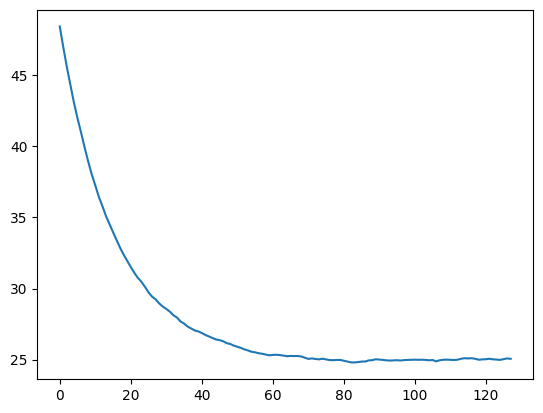

In [27]:
results = sample_func(jr.PRNGKey(2), num_samples, 
                    #   k=4, 
                    #   gibbs_temperature=1.0, 
                    #   maskgit_temperature=1.,
                      corrector_step_size=2.0)
xs = results["corrected"][:, -1]
# print(f"Mean run length of generated samples: {mean_run_length(xs)}")
# print(f"Error rate of generated samples: {error_rate(xs)}")
states_path = results["corrected"]
# states_path = jnp.where(states_path == MASK, jnp.nan, states_path)
mask_count = jnp.sum(states_path == MASK, axis=-1)
mask_count = jnp.mean(mask_count, axis=0)
plt.plot(mask_count)

/tmp/ipykernel_193963/730060671.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


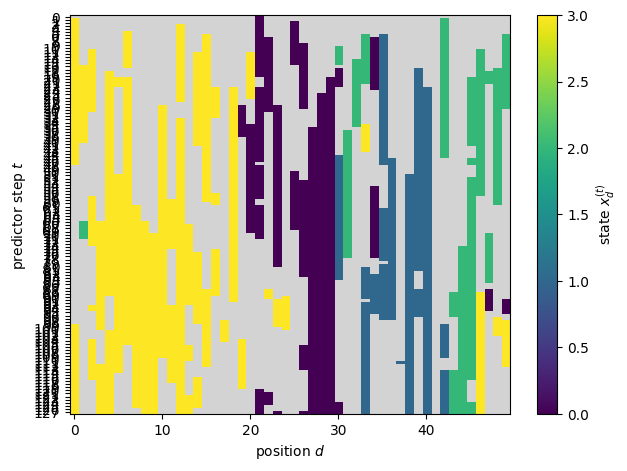

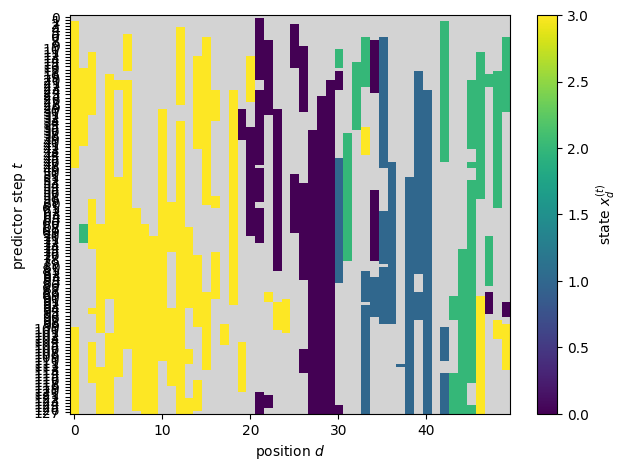

In [33]:
import matplotlib.cm as cm

id = 5
states_path = results["corrected"][id]
states_path = jnp.where(states_path == MASK, jnp.nan, states_path)

cmap = cm.get_cmap("viridis")
cmap.set_bad("lightgray")
plt.imshow(states_path, interpolation="none",
           vmin=0, vmax=num_states-1, cmap=cmap,
           aspect="auto")
plt.ylabel(r"predictor step $t$")
plt.xlabel(r"position $d$")
plt.yticks(jnp.arange(config["num_steps"]))
plt.tight_layout()
plt.colorbar(label=r"state $x_d^{(t)}$")
# plt.title(rf"seed={seed}, $N_P={num_predictor_tokens}$, $N_C={num_corrector_tokens}$")
plt.figure()
states_path = results["predicted"][id]
states_path = jnp.where(states_path == MASK, jnp.nan, states_path)
plt.imshow(states_path, interpolation="none",
           vmin=0, vmax=num_states-1, cmap=cmap,
           aspect="auto")
plt.ylabel(r"predictor step $t$")
plt.xlabel(r"position $d$")
plt.yticks(jnp.arange(config["num_steps"]))
plt.tight_layout()
plt.colorbar(label=r"state $x_d^{(t)}$")
# plt.title(rf"seed={seed}, $N_P={num_predictor_tokens}$, $N_C={num_corrector_tokens}$")

## Testing the quality of the samples
Compute distribution of test statistics under the true Markov chain ($q$) and the predictor/corrector samples ($p$).

```
t_1(x) = number of errors in x
t_2(x) = 1/(T-1) \sum_{t=1}^{T-1} I[x_t = x_{t+1}]
t_3(x) = 1/T \sum_t I[x = k] for k=1,...,K
...
```

In [57]:
@jax.jit
def mean_run_length(x):
    x = x.flatten()
    changes = jnp.diff(x) != 0
    changes = jnp.append(changes, True)
    run_count = jnp.sum(changes)
    idx = jnp.arange(len(changes))
    run_lengths = jnp.diff(jnp.sort(changes * idx))
    
    return (jnp.sum(run_lengths) + 1) / run_count

@jax.jit
def error_rate_single(x):
    """
    Compute the error rate of a single sequence.
    """
    diff = jnp.diff(x) % num_states
    return jnp.mean((diff != 0) * (diff != 1))

def error_rate(xs):
    """
    Compute the error rate of a batch of sequences.
    """
    N = xs.shape[0]
    return jnp.mean(jax.vmap(error_rate_single)(xs))

In [129]:
config = {
    "forward_process": CosineSchedule(),
    "predictor_type": "md4",
    "corrector_type": "forward_backward",
    "num_steps": 32,
    "anneal_temperature": True
}

sample_func = make_sample_func(config)

In [130]:
num_samples = 1000

results = sample_func(jr.PRNGKey(2), num_samples, 
                    #   k=4, 
                    #   gibbs_temperature=1.0, 
                    #   maskgit_temperature=1.,
                      corrector_step_size=0.0)
xs = results["corrected"][:, -1]
print(f"Mean run length of generated samples: {mean_run_length(xs)}")
print(f"Error rate of generated samples: {error_rate(xs)}")

Mean run length of generated samples: 7.510890960693359
Error rate of generated samples: 0.00483673345297575


In [85]:
num_samples = 1000

results = sample_func(jr.PRNGKey(2), num_samples, 
                    #   k=4, 
                    #   gibbs_temperature=1.0, 
                    #   maskgit_temperature=1.,
                      corrector_step_size=0.0000)
xs = results["corrected"][:, -1]
print(f"Mean run length of generated samples: {mean_run_length(xs)}")
print(f"Error rate of generated samples: {error_rate(xs)}")

Mean run length of generated samples: 6.501949787139893
Error rate of generated samples: 0.009204081259667873


In [62]:
config = {
    "forward_process": CosineSchedule(),
    "predictor_type": "md4",
    "corrector_type": "none",
    "num_steps": 32,
    "anneal_temperature": True
}

sample_func = make_sample_func(config)
num_samples = 1000

results = sample_func(jr.PRNGKey(2), num_samples, 
                    #   k=4, 
                    #   gibbs_temperature=1.0, 
                    #   maskgit_temperature=1.,
                      corrector_step_size=0.1)
xs = results["corrected"][:, -1]
print(f"Mean run length of generated samples: {mean_run_length(xs)}")
print(f"Error rate of generated samples: {error_rate(xs)}")

Mean run length of generated samples: 7.510890960693359
Error rate of generated samples: 0.00483673345297575


In [128]:
results["corrected"].shape

(1000, 9, 128)

# Parameter sweep

In [131]:
import pandas as pd
import os
import itertools

In [133]:
num_states = 4
seq_len = 128
self_trans_prob = 0.9
num_samples = 1000
num_repeats = 5

trans_matrix = self_trans_prob * jnp.eye(num_states) \
             + (1 - self_trans_prob) * jnp.roll(jnp.eye(num_states), 1, axis=1)

file_name = f"mc_{num_states}states_p={self_trans_prob}_1_30_fb.csv"
# csv_file = os.path.join(logfile_name)
csv_file = file_name
print(csv_file)

mc_4states_p=0.9_1_30_fb.csv


In [137]:
if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
else:
    df = pd.DataFrame(columns=['seed', 'nfe', 'forward_process', 'predictor_type', 'corrector_type',
                               'num_steps', 'gibbs_k', 'gibbs_temperature', 'anneal_temperature',
                               'maskgit_temperature', 'corrector_step_size', 'avg_run_length', 'error_rate'])
    
forward_processes = [CosineSchedule(), LinearSchedule()]
num_psteps = [16, 32, 64, 128] # Not running 8 for now
predictor_types = ["md4", 
                #    "maskgit"
                   ]
corrector_types = [
                    "forward_backward"
                    # "none", 
                #    "gibbs", 
                #    "gibbs_argmax"
                   ]
anneal_temperatures = [
                       True, 
                    #    False
                       ]
# num_csteps = [1,] # We always assume 1 cstep
# entry_times = [.9, .5] # We are not adding entry time in this setup

gibbs_ks = [
    0,
    # 1, 2, 4, 8, 16
    ]
maskgit_temperatures = [
    0.,
    # 0.01, .1, .5, 1., 2., 4.
    ]
gibbs_temperatures = [
    0.,
    # 0.01, .1, .5, 1., 2., 4.
    ]

corrector_step_sizes = [
    0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0
]

# no_corrector_experiments = itertools.product(
#       methods[:1], num_csteps[:1], entry_times[:1], 
#       cstep_sizes[:1], num_psteps, [None])

params_combination = itertools.product(forward_processes, num_psteps, predictor_types, 
                                       corrector_types, anneal_temperatures)

# Define config here
config = {}

def run_and_log_results(p_sample, seed, config, gibbs_k=None, gibbs_temperature=None,
                        maskgit_temperature=None, corrector_step_size=None):

    # Read the csv file
    # If the experiment has already been run, skip it
    global df

    if len(df) > 0:
        if df[(df['seed'] == seed)
            & (df['anneal_temperature'] == config.get("anneal_temperature"))
            & (df['forward_process'] == config["forward_process"].__class__.__name__)
            & (df['predictor_type'] == config["predictor_type"])
            & (df['corrector_type'] == config["corrector_type"])
            & (df['num_steps'] == config["num_steps"])
            & (df['gibbs_k'] == gibbs_k)
            & (df['gibbs_temperature'] == gibbs_temperature)
            & (df['maskgit_temperature'] == maskgit_temperature)
            & (df['corrector_step_size'] == corrector_step_size)
            ].shape[0] > 0:
            print("Experiment already run, skipping...")
            return

    samples = p_sample(jr.PRNGKey(seed), num_samples, 
                       k=gibbs_k, gibbs_temperature=gibbs_temperature,
                       maskgit_temperature=maskgit_temperature,
                       corrector_step_size=corrector_step_size)
    xs = samples["corrected"][:, -1]
    mean_run = mean_run_length(xs)
    err = error_rate(xs)

    nfe = config["num_steps"]
    if config["corrector_type"] != "none": nfe *= 2
    if "argmax" in config["corrector_type"]: nfe += 1

    results = {
        'seed': [seed],
        'nfe': [nfe],
        'forward_process': [config["forward_process"].__class__.__name__],
        'predictor_type': [config["predictor_type"]],
        'corrector_type': [config["corrector_type"]],
        'num_steps': [config["num_steps"]],
        'gibbs_k': [gibbs_k],
        'gibbs_temperature': [gibbs_temperature],
        'anneal_temperature': [config.get("anneal_temperature")],
        'maskgit_temperature': [maskgit_temperature],
        'corrector_step_size': [corrector_step_size],
        'avg_run_length': [mean_run],
        'error_rate': [err],
    }

    print(results)

    df = pd.concat([df, pd.DataFrame(results)], ignore_index=True)
    df.to_csv(csv_file, index=False)

for forward_process, num_pstep, predictor_type, corrector_type, anneal_temperature in params_combination:

    config["forward_process"] = forward_process
    config["num_steps"] = num_pstep
    config["predictor_type"] = predictor_type
    config["corrector_type"] = corrector_type
    config["anneal_temperature"] = anneal_temperature
    
    if predictor_type == "maskgit" and corrector_type != "none":
        # We're not interested in this combination for now
        continue

    if corrector_type != "none":
        # Half the steps are corrector steps
        config["num_steps"] = num_pstep // 2
    
    if "gibbs" not in corrector_type and predictor_type == "md4":
        # No temperature is needed
        config["anneal_temperature"] = False

    p_sample = make_sample_func(config)

    _maskgit_temperatures = [None]
    _gibbs_temperatures = [None]
    _gibbs_ks = [None]
    _corrector_step_sizes = [None]

    if predictor_type == "maskgit":
        _maskgit_temperatures = maskgit_temperatures
    elif "gibbs" in corrector_type:
        _gibbs_temperatures = gibbs_temperatures
        _gibbs_ks = gibbs_ks
    elif corrector_type == "forward_backward":
        _corrector_step_sizes = corrector_step_sizes

    inner_params_conbinations = itertools.product(_maskgit_temperatures, _gibbs_ks, _gibbs_temperatures, _corrector_step_sizes)

    for maskgit_temperature, gibbs_k, gibbs_temperature, corrector_step_size in inner_params_conbinations:
        for seed in range(num_repeats):
            run_and_log_results(p_sample, seed, config, gibbs_k=gibbs_k, 
                                    gibbs_temperature=gibbs_temperature,
                                    maskgit_temperature=maskgit_temperature,
                                    corrector_step_size=corrector_step_size)
            # except:
            #     print('====== Experiment failed due to an unknown reason, moving on... ======')

{'seed': [0], 'nfe': [16], 'forward_process': ['CosineSchedule'], 'predictor_type': ['md4'], 'corrector_type': ['forward_backward'], 'num_steps': [8], 'gibbs_k': [None], 'gibbs_temperature': [None], 'anneal_temperature': [False], 'maskgit_temperature': [None], 'corrector_step_size': [0.01], 'avg_run_length': [Array(5.3169394, dtype=float32)], 'error_rate': [Array(0.02072441, dtype=float32)]}
{'seed': [1], 'nfe': [16], 'forward_process': ['CosineSchedule'], 'predictor_type': ['md4'], 'corrector_type': ['forward_backward'], 'num_steps': [8], 'gibbs_k': [None], 'gibbs_temperature': [None], 'anneal_temperature': [False], 'maskgit_temperature': [None], 'corrector_step_size': [0.01], 'avg_run_length': [Array(5.2737837, dtype=float32)], 'error_rate': [Array(0.02098425, dtype=float32)]}


/tmp/ipykernel_184471/3654147282.py:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame(results)], ignore_index=True)


{'seed': [2], 'nfe': [16], 'forward_process': ['CosineSchedule'], 'predictor_type': ['md4'], 'corrector_type': ['forward_backward'], 'num_steps': [8], 'gibbs_k': [None], 'gibbs_temperature': [None], 'anneal_temperature': [False], 'maskgit_temperature': [None], 'corrector_step_size': [0.01], 'avg_run_length': [Array(5.2997684, dtype=float32)], 'error_rate': [Array(0.02066142, dtype=float32)]}
{'seed': [3], 'nfe': [16], 'forward_process': ['CosineSchedule'], 'predictor_type': ['md4'], 'corrector_type': ['forward_backward'], 'num_steps': [8], 'gibbs_k': [None], 'gibbs_temperature': [None], 'anneal_temperature': [False], 'maskgit_temperature': [None], 'corrector_step_size': [0.01], 'avg_run_length': [Array(5.34804, dtype=float32)], 'error_rate': [Array(0.02046457, dtype=float32)]}
{'seed': [4], 'nfe': [16], 'forward_process': ['CosineSchedule'], 'predictor_type': ['md4'], 'corrector_type': ['forward_backward'], 'num_steps': [8], 'gibbs_k': [None], 'gibbs_temperature': [None], 'anneal_tempe

# Random little tests

In [40]:
# @title Testing baseline without correctors

config = {
    "forward_process": None,
    "predictor_type": "unmask_k",
    "corrector_type": "none",
    "num_predictor_tokens": 50 // 16 + 1,
    "num_steps": 16,
}

results = jax.vmap(partial(sample, trans_matrix=trans_matrix, seq_length=seq_len, sample_config=config))\
    (jr.split(jr.PRNGKey(seed), num_samples))
xs = results["corrected"][:,-1]

print(f"Mean run length of generated samples: {mean_run_length(xs)}")
print(f"Mean run length of real samples: {mean_run_length(real_samples)}")
print(f"Error rate of generated samples: {error_rate(xs)}")
print(f"Error rate of real samples: {error_rate(real_samples)}")

Collected samples, now computing statistics
Mean run length of generated samples: 1.8489093780517578
Mean run length of real samples: 9.560087203979492
Error rate of generated samples: 0.2584724724292755
Error rate of real samples: 0.0


In [24]:
# @title Testing baseline with correctors

config = {
    "forward_process": None,
    "predictor_type": "unmask_k",
    "corrector_type": "gibbs",
    # "corrector_type": "unmask_k",
    "num_predictor_tokens": 50 // 8 + 1,
    "num_corrector_tokens": 1,
    "gibbs_k": 3,
    "gibbs_temperature": 0.01,
    "num_steps": 8,
}

results = jax.vmap(partial(sample, trans_matrix=trans_matrix, seq_length=seq_len, sample_config=config))\
    (jr.split(jr.PRNGKey(seed), num_samples))
xs = results["corrected"][:,-1]

print(f"Mean run length of generated samples: {mean_run_length(xs)}")
print(f"Mean run length of real samples: {mean_run_length(real_samples)}")
print(f"Error rate of generated samples: {error_rate(xs)}")
print(f"Error rate of real samples: {error_rate(real_samples)}")

Mean run length of generated samples: 6.598047256469727
Mean run length of real samples: 8.564577102661133
Error rate of generated samples: 0.0033673460129648447
Error rate of real samples: 0.0
